In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(compositions)
library(ecodist)
library(ggstatsplot)
library(patchwork)
library(cowplot)

── Attaching core tidyverse packages ─────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ───────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Welcome to compositions, a package for compositional data analysis.yverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conf

# File sorting============================================================================================================

In [2]:
# Read taxa data
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/2025-11-11_vaginal_taxa_filtered.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
dim(taxa_tab)
head(taxa_tab)

[1]  65 175

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.38593,0.00000,0.00000,0.00000
Aerococcus christensenii,0.00000,0,0.37028,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.00000,0.00000,0.23952,0.00000
Alloscardovia omnicolens,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00197,0.00000,0,1.74307,0,0.00000,0.00509,0.00000,0.71791
Anaerococcus hydrogenalis,0.00697,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00420,0,0.00319,0.00000,0.00000,0.00000
Anaerococcus lactolyticus,0.01879,0,0.00000,0,0.00000,0,0.00013,0,0,0.00035,⋯,0,0.00000,0.00062,0,0.02457,0,0.00000,0.00166,0.00000,0.00000
Anaerococcus prevotii,0.00000,0,0.00000,0,0.01267,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00989,0,0.00000,0.00000,0.00000,0.00000


In [3]:
colnames(taxa_tab)

[1] "FF00653546" "FF00653544" "FB02825409" "FF03817116" "FF01566745"
  [6] "FF02556135" "FF03818430" "FF01571976" "FF06040450" "FF06039085"
 [11] "FF06039956" "FF06039601" "FF06039627" "FF06039861" "FF03817982"
 [16] "FF05043974" "FF05044855" "FF05044200" "FF01570382" "FF06032885"
 [21] "FF06040007" "FF06579566" "FF06580410" "FF03815366" "FF01571067"
 [26] "FF01570828" "FF02015345" "FF02015010" "FF00653065" "FF00530476"
 [31] "FF02014263" "FF02015432" "FF02015296" "FF03817626" "FF05024757"
 [36] "FF05024748" "FF08440350" "FF04761480" "FF06040483" "FF06033048"
 [41] "FF06580418" "FF00657563" "FF00653167" "FF00657544" "FF00657476"
 [46] "FF06039868" "FF06039595" "FF06039831" "FF06039830" "FF05024953"
 [51] "FF05043336" "FF04023664" "FF02557868" "FF02556105" "FF02015815"
 [56] "FF06580399" "FF04761460" "FF01570782" "FF01570777" "FF05025296"
 [61] "FF01572419" "FF05025294" "FF05043003" "FF05025300" "FF05043036"
 [66] "FF02015546" "FF02739091" "FB02846091" "FF00620268" "FF00653071"
 [71] "FF00657923" "FF02014181" "FF03817636" "FF02555999" "FF00652411"
 [76] "FF00941094" "FF02014833" "FF00651927" "FF00530460" "FF02556090"
 [81] "FF00619356" "FF00531139" "FF00530247" "FF02740674" "FF00657534"
 [86] "FF00653507" "FF00652106" "FF02015011" "FF03816378" "FF03816924"
 [91] "FF00531215" "FF00530208" "FF00530163" "FF02014805" "FF00653014"
 [96] "FF00652988" "FF00531719" "FF01572430" "FF08440357" "FF04761496"
[101] "FF08440702" "FF05044402" "FF02740612" "FF06039064" "FF06743148"
[106] "FF04761509" "FF04761505" "FF06580438" "FF00652209" "FF03818217"
[111] "FF02014450" "FF02014344" "FF05044198" "FF00653280" "FF04761535"
[116] "FF02557890" "FF03817815" "FF03817183" "FF03817972" "FF03816858"
[121] "FF03818246" "FF02557245" "FF02015423" "FF05024823" "FF02015861"
[126] "FF02013773" "FF06580149" "FF00531053" "FF03818104" "FF03815388"
[131] "FF01570606" "FF03816408" "FF00531062" "FF01572330" "FF06743126"
[136] "FF06032176" "FF00657220" "FF00653474" "FF00531725" "FF00658016"
[141] "FF06039851" "FF00657251" "FF00531455" "FF03816395" "FF01572371"
[146] "FF01572506" "FF02014735" "FF02015041" "FF02740077" "FF08440262"
[151] "FF06581586" "FF06033016" "FF00531275" "FF04760553" "FF03816396"
[156] "FF00620158" "FF06032916" "FB02825218" "FF06743139" "FF00619973"
[161] "FF00530529" "FF01570524" "FB02846907" "FF04761515" "FF00657243"
[166] "FF05044395" "FF04760422" "FF00531801" "FF08440403" "FF08440398"
[171] "FF08440427" "FF03818480" "FF08440674" "FF08440393" "FF06039070"

In [4]:
taxa_tab[, 1]

[1]  0.00000  0.00000  0.00000  0.00697  0.01879  0.00000  0.00623  0.00000
 [9]  0.00000  0.01103  0.00000  0.00000  0.00000  0.00000  0.00052  0.13072
[17]  0.00957  0.02022  0.01255  0.00000  0.02617  0.00000  0.00000  0.01227
[25]  0.06033  0.10261  0.00000  0.00000  0.00000  0.00000  0.03241  0.00000
[33] 98.22154  0.00000  0.03729  0.70713  0.02794  0.00000  0.00000  0.00000
[41]  0.00000  0.04244  0.00738  0.05611  0.03749  0.00000  0.00000  0.00000
[49]  0.01996  0.13944  0.00000  0.01501  0.10168  0.00000  0.00000  0.00000
[57]  0.00000  0.00000  0.00000  0.00000  0.00805  0.00000  0.02838  0.00000
[65]  0.09977

In [5]:
tail(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ureaplasma parvum,0.00000,0.05158,0.00970,0.00000,0,0,0.03087,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.06229,0.00000,0.22328,0.93376,0.00000,0.00000,0.22960
Varibaculum cambriense,0.00805,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.01344,0.00000,0.02252,0.00000,0.00000,0.00000
Varibaculum massiliense,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.04088,0.00000,0.00000,0.00000,0.00000,0.00000,0.40982,0.00000,0.00000,0.01783
Veillonellaceae bacterium_DNF00626,0.02838,0.00000,0.90706,0.00000,0,0,0.01367,0,0.00000,0.00000,⋯,0.01054,0.00000,0.00000,0.00000,0.35534,0.00131,0.00000,0.00000,0.02001,0.00000
Winkia neuii,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.12902,0.00000,0.00000,0.00000,0.00000,0.00000
Other_taxa,0.09977,0.00000,0.80965,0.00544,0,0,0.06051,0,0.08047,0.01244,⋯,1.14737,2.24081,0.00757,0.02786,0.24871,0.77614,0.71443,0.10985,0.63242,0.03292


In [6]:
colSums(taxa_tab)

FF00653546 FF00653544 FB02825409 FF03817116 FF01566745 FF02556135 FF03818430 
       100        100        100        100        100        100        100 
FF01571976 FF06040450 FF06039085 FF06039956 FF06039601 FF06039627 FF06039861 
       100        100        100        100        100        100        100 
FF03817982 FF05043974 FF05044855 FF05044200 FF01570382 FF06032885 FF06040007 
       100        100        100        100        100        100        100 
FF06579566 FF06580410 FF03815366 FF01571067 FF01570828 FF02015345 FF02015010 
       100        100        100        100        100        100        100 
FF00653065 FF00530476 FF02014263 FF02015432 FF02015296 FF03817626 FF05024757 
       100        100        100        100        100        100        100 
FF05024748 FF08440350 FF04761480 FF06040483 FF06033048 FF06580418 FF00657563 
       100        100        100        100        100        100        100 
FF00653167 FF00657544 FF00657476 FF06039868 FF06039595 FF06039831 FF06039830 
       100        100        100        100        100        100        100 
FF05024953 FF05043336 FF04023664 FF02557868 FF02556105 FF02015815 FF06580399 
       100        100        100        100        100        100        100 
FF04761460 FF01570782 FF01570777 FF05025296 FF01572419 FF05025294 FF05043003 
       100        100        100        100        100        100        100 
FF05025300 FF05043036 FF02015546 FF02739091 FB02846091 FF00620268 FF00653071 
       100        100        100        100        100        100        100 
FF00657923 FF02014181 FF03817636 FF02555999 FF00652411 FF00941094 FF02014833 
       100        100        100        100        100        100        100 
FF00651927 FF00530460 FF02556090 FF00619356 FF00531139 FF00530247 FF02740674 
       100        100        100        100        100        100        100 
FF00657534 FF00653507 FF00652106 FF02015011 FF03816378 FF03816924 FF00531215 
       100        100        100        100        100        100        100 
FF00530208 FF00530163 FF02014805 FF00653014 FF00652988 FF00531719 FF01572430 
       100        100        100        100        100        100        100 
FF08440357 FF04761496 FF08440702 FF05044402 FF02740612 FF06039064 FF06743148 
       100        100        100        100        100        100        100 
FF04761509 FF04761505 FF06580438 FF00652209 FF03818217 FF02014450 FF02014344 
       100        100        100        100        100        100        100 
FF05044198 FF00653280 FF04761535 FF02557890 FF03817815 FF03817183 FF03817972 
       100        100        100        100        100        100        100 
FF03816858 FF03818246 FF02557245 FF02015423 FF05024823 FF02015861 FF02013773 
       100        100        100        100        100        100        100 
FF06580149 FF00531053 FF03818104 FF03815388 FF01570606 FF03816408 FF00531062 
       100        100        100        100        100        100        100 
FF01572330 FF06743126 FF06032176 FF00657220 FF00653474 FF00531725 FF00658016 
       100        100        100        100        100        100        100 
FF06039851 FF00657251 FF00531455 FF03816395 FF01572371 FF01572506 FF02014735 
       100        100        100        100        100        100        100 
FF02015041 FF02740077 FF08440262 FF06581586 FF06033016 FF00531275 FF04760553 
       100        100        100        100        100        100        100 
FF03816396 FF00620158 FF06032916 FB02825218 FF06743139 FF00619973 FF00530529 
       100        100        100        100        100        100        100 
FF01570524 FB02846907 FF04761515 FF00657243 FF05044395 FF04760422 FF00531801 
       100        100        100        100        100        100        100 
FF08440403 FF08440398 FF08440427 FF03818480 FF08440674 FF08440393 FF06039070 
       100        100        100        100        100        100        100

In [7]:
taxa <- as.data.frame(t(taxa_tab))
class(taxa)
head(taxa)

[1] "data.frame"

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF00653546,0,0.00000,0,0.00697,0.01879,0.00000,0.00623,0.00000,0,0.01103,⋯,0,0,0,0.00000,0.00000,0.00805,0,0.02838,0,0.09977
FF00653544,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.05158,0.00000,0,0.00000,0,0.00000
FB02825409,0,0.37028,0,0.00000,0.00000,0.00000,0.00000,0.00477,0,0.00000,⋯,0,0,0,0.25771,0.00970,0.00000,0,0.90706,0,0.80965
FF03817116,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00544
FF01566745,0,0.00000,0,0.00000,0.00000,0.01267,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00000
FF02556135,0,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0,0.00000,⋯,0,0,0,0.00000,0.00000,0.00000,0,0.00000,0,0.00000


In [8]:
# Read metadata
combined_meta_tp2 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp2_nulliparous//2025-11-11_combined_fp_sp_tp2.csv", header = TRUE, row.names = 1)
head(combined_meta_tp2)
dim(combined_meta_tp2 )

,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,Age_groups,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>,<chr>
5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,4,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,3,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,First pregnancy
5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,3,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,First pregnancy
5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,2,⋯,NA,NA,NA,NA,41,Spontaneous,NA,NA,0,First pregnancy
5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,4,⋯,NA,NA,NA,NA,38,Induction,NA,NA,0,First pregnancy
5239,S5fa4a39,NA,0,0,0,2018-08-30,P4de45e7,0,29,2,⋯,NA,NA,NA,NA,39,Induction,NA,NA,1,First pregnancy


[1]  32 566

In [9]:
variables_tp2 <- combined_meta_tp2 |>
    select(Group, Studienummer, Q1_Personnummer, age_checked, Age_groups, excess_weight, Weight_before_C, BMI_prior, kit2.vaginal_sample.barcode, Primipara,
          Q2_X25_Smoking_snus_now, Q2_X28_How_often_alcohol_since_pregnancy, Q2_X6.Antibiotics_during_pregnancy, stress_sum_score_Q2,BMI_now_3_groups)

In [10]:
dim(variables_tp2)
head(variables_tp2)

[1] 32 15

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.vaginal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,Nej,Aldrig,0,1,25
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,Nej,Aldrig,0,12,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,Nej,Aldrig,0,5,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,Nej,Aldrig,1,8,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,Nej,Aldrig,0,6,25
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,Nej,Aldrig,0,5,> 25 Overweight


In [11]:
# Convert to fitting data types
variables_tp2$excess_weight <- as.factor(variables_tp2$excess_weight)
class(variables_tp2$excess_weight)

variables_tp2$kit2.vaginal_sample.barcode <- as.character(variables_tp2$kit2.vaginal_sample.barcode)
class(variables_tp2$kit2.vaginal_sample.barcode)

variables_tp2$Primipara <- as.factor(variables_tp2$Primipara)
class(variables_tp2$Primipara)

head(variables_tp2)

[1] "factor"

[1] "character"

[1] "factor"

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.vaginal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,Nej,Aldrig,0,1,25
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,Nej,Aldrig,0,12,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,Nej,Aldrig,0,5,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,Nej,Aldrig,1,8,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,Nej,Aldrig,0,6,25
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,Nej,Aldrig,0,5,> 25 Overweight


In [12]:
head(variables_tp2)

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.vaginal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<chr>,<chr>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,Nej,Aldrig,0,1,25
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,Nej,Aldrig,0,12,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,Nej,Aldrig,0,5,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,Nej,Aldrig,1,8,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,Nej,Aldrig,0,6,25
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,Nej,Aldrig,0,5,> 25 Overweight


In [13]:
# Convert smoking to categories 
smoking_category <- ifelse(variables_tp2$Q2_X25_Smoking_snus_now == "Nej", 0, ifelse(variables_tp2$Q2_X25_Smoking_snus_now == "Ja", 1, NA))
(smoking_category)
variables_tp2$Q2_X25_Smoking_snus_now <- as.factor(smoking_category)
head(variables_tp2)

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.vaginal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<chr>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,0,Aldrig,0,1,25
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,0,Aldrig,0,12,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,0,Aldrig,0,5,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,0,Aldrig,1,8,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,0,Aldrig,0,6,25
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,0,Aldrig,0,5,> 25 Overweight


In [14]:
smoking_category

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [15]:
#variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy
# Convert alcohol to categories 
alcohol_category <- ifelse(variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Aldrig", 0, 
                           ifelse(variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy == "Ja", 1, NA))
alcohol_category
variables_tp2$Q2_X28_How_often_alcohol_since_pregnancy <- as.factor(alcohol_category)
head(variables_tp2)

[1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

,Group,Studienummer,Q1_Personnummer,age_checked,Age_groups,excess_weight,Weight_before_C,BMI_prior,kit2.vaginal_sample.barcode,Primipara,Q2_X25_Smoking_snus_now,Q2_X28_How_often_alcohol_since_pregnancy,Q2_X6.Antibiotics_during_pregnancy,stress_sum_score_Q2,BMI_now_3_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<int>,<int>,<chr>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,0,0,0,1,25
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,0,0,0,12,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,0,0,0,5,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,0,0,1,8,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,0,0,0,6,25
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,0,0,0,5,> 25 Overweight


In [16]:
# Convert antibiotics to fct
variables_tp2$Q2_X6.Antibiotics_during_pregnancy <- as.factor(variables_tp2$Q2_X6.Antibiotics_during_pregnancy)
class(variables_tp2$Q2_X6.Antibiotics_during_pregnancy)
head(variables_tp2$Q2_X6.Antibiotics_during_pregnancy )

[1] "factor"

[1] 0 0 0 1 0 0
Levels: 0 1

In [17]:
# Stress into categories
high_stress <- ifelse(variables_tp2$stress_sum_score_Q2 >= 7, 1, ifelse(variables_tp2$stress_sum_score_Q2 < 7 , 0, NA))
high_stress
length(variables_tp2$stress_sum_score_Q2)


[1] 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0

[1] 32

In [18]:
variables_tp2$stress_sum_score_Q2 <- as.factor(high_stress)
class(variables_tp2$stress_sum_score_Q2)
head(variables_tp2$stress_sum_score_Q2)

[1] "factor"

[1] 0 1 0 1 0 0
Levels: 0 1

In [19]:
# Group bmi groups
bmi_levels <- c("< 18.5 Underweight", "18.5-25 Normal weight", "> 25 Overweight")
bmi_levels
variables_tp2$BMI_now_3_groups <- factor(variables_tp2$BMI_now_3_groups, levels = bmi_levels)
class(variables_tp2$BMI_now_3_groups)

[1] "< 18.5 Underweight"    "18.5-25 Normal weight" "> 25 Overweight"

[1] "factor"

In [20]:
# Create a table with relevant variables
adonis_tab_tp2 <- variables_tp2 |> rename(Studynumber = Studienummer, Personalnumber = Q1_Personnummer, Age = age_checked, 
                                          Sample_ID = kit2.vaginal_sample.barcode, Smoking = Q2_X25_Smoking_snus_now, 
                                          Alcohol = Q2_X28_How_often_alcohol_since_pregnancy, Antibiotics = Q2_X6.Antibiotics_during_pregnancy,
                                          High_stress = stress_sum_score_Q2, BMI_groups = BMI_now_3_groups)
head(adonis_tab_tp2)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,First pregnancy,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,0,0,0,0,NA
5258,First pregnancy,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,0,0,0,1,18.5-25 Normal weight
5275,First pregnancy,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,0,0,0,0,18.5-25 Normal weight
5243,First pregnancy,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,0,0,1,1,18.5-25 Normal weight
5383,First pregnancy,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,0,0,0,0,NA
5239,First pregnancy,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,0,0,0,0,> 25 Overweight


In [21]:
# Rename groups for ease of reading plots
adonis_tab_tp2$Group <- ifelse(adonis_tab_tp2$Group == "First pregnancy ", "Nulliparous", 
                                   ifelse(adonis_tab_tp2$Group == "Second pregnancy", "Primiparous", NA))
head(adonis_tab_tp2)

,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Sample_ID,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
5367,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,FF00531801,1,0,0,0,0,NA
5258,Nulliparous,S1f95844,P1f95844,30,3,No,64,22,FF02014735,1,0,0,0,1,18.5-25 Normal weight
5275,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,FF03816858,1,0,0,0,0,18.5-25 Normal weight
5243,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,FF02015861,1,0,0,1,1,18.5-25 Normal weight
5383,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,FF00657251,1,0,0,0,0,NA
5239,Nulliparous,S5fa4a39,P4de45e7,29,2,Yes,71,28,FF02015423,1,0,0,0,0,> 25 Overweight


In [22]:
adonis_tab_tp2$Group <- as.factor(adonis_tab_tp2$Group)
class(adonis_tab_tp2$Group)
#head(adonis_tab_tp2)

[1] "factor"

In [23]:
table(adonis_tab_tp2$Group)
#grep("BMI", names(combined_meta_tp1), value =TRUE )


Nulliparous Primiparous 
         16          16 

In [24]:
# Extract barcodes
barcodes <- adonis_tab_tp2$Sample_ID
length(barcodes)

[1] 32

In [25]:
taxa_tp1 <- taxa[, colnames(taxa) %in% barcodes]
dim(taxa_tp1)  

[1] 175   0

In [26]:
adonis_tab_tp2$Sample_ID
length(unique(rownames(taxa)))

[1] "FF00531801" "FF02014735" "FF03816858" "FF02015861" "FF00657251"
 [6] "FF02015423" "FF00657220" "FF00531275" "FF02014450" "FF02740077"
[11] "FF02557245" "FF02014344" "FF00619973" "FB02825218" "FF00531062"
[16] "FF02740612" "FF06580149" "FF08440398" "FF06032916" "FF01572330"
[21] "FF08440702" "FF04761496" "FF06039851" "FF06743126" "FF06032176"
[26] "FF08440357" "FF04761515" "FF06743139" "FF08440262" "FF08440427"
[31] "FF06033016" "FF05024823"

[1] 175

In [27]:
# Extraxt taxa TP1
taxa_kit2 <- taxa[rownames(taxa) %in% barcodes, ]
head(taxa_kit2)
dim(taxa_kit2)
#head (taxa)

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF08440357,0,0.00000,0.00000,0,0.00000,0.00849,0.00595,0.00000,0.00000,0.00000,⋯,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0.00000,0.00403
FF04761496,0,0.00000,0.00000,0,0.00566,0.00000,0.00000,0.00906,0.00000,0.03837,⋯,0,0.35842,4.39279,0,0,0,0.68431,0.00000,1.21159,0.52367
FF08440702,0,1.80036,0.09341,0,0.00000,0.00000,0.00000,0.00000,0.00262,0.00767,⋯,0,0.00227,0.00000,0,0,0,0.00000,0.21566,0.00000,0.54450
FF02740612,0,0.00000,0.00000,0,0.05158,0.00686,0.00000,0.00000,0.00000,0.00000,⋯,0,0.00101,0.00000,0,0,0,0.00000,0.00000,0.00172,0.03108
FF02014450,0,0.00000,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00700,⋯,0,0.00000,0.01484,0,0,0,0.00000,0.02097,0.00000,0.03626
FF02014344,0,0.00000,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0,0.00000,0.02369,0,0,0,0.00000,0.24073,0.00000,0.00000


[1] 32 65

In [28]:
# Order taxa according to meta data file, so they are in the same order
# Factor to convert rownames and adonis to deffine order

ordered_taxa <- taxa_kit2 |> arrange(factor(rownames(taxa_kit2), level = adonis_tab_tp2$Sample_ID))
#adonis_tab$Sample_ID
head(ordered_taxa)
head(adonis_tab_tp2$Sample_ID)
dim(adonis_tab_tp2)

,Actinobaculum massiliense,Aerococcus christensenii,Alloscardovia omnicolens,Anaerococcus hydrogenalis,Anaerococcus lactolyticus,Anaerococcus prevotii,Anaerococcus sp_Marseille_P3915,Anaerococcus tetradius,Anaerococcus vaginalis,Atopobium deltae,⋯,Staphylococcus epidermidis,Streptococcus anginosus,Streptococcus SGB3665,Tissierellia bacterium_KA00581,Ureaplasma parvum,Varibaculum cambriense,Varibaculum massiliense,Veillonellaceae bacterium_DNF00626,Winkia neuii,Other_taxa
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF00531801,0,0.00000,0.00000,0,0.00062,0.00000,0.00000,0.00000,0.0000,0,⋯,0,0.00000,0.00000,0.00000,0.00000,0.000,0.00000,0.00000,0,0.00757
FF02014735,0,0.00000,0.00000,0,0.00000,0.00927,0.01325,0.00000,0.0000,0,⋯,0,0.00000,0.00163,0.00000,0.07169,0.000,0.00000,0.00431,0,0.00746
FF03816858,0,0.00000,0.00000,0,0.00000,0.00000,0.00000,0.00000,0.0000,0,⋯,0,0.00000,0.00000,0.00000,0.00000,0.000,0.00000,0.00000,0,0.00000
FF02015861,0,0.50963,0.00000,0,0.00000,0.00000,0.00000,0.01127,0.0000,0,⋯,0,0.00000,0.00000,0.23507,0.00033,0.000,0.00000,0.21450,0,0.29344
FF00657251,0,0.65759,0.50312,0,0.13764,0.00000,0.00000,0.00000,0.1004,0,⋯,0,0.00000,0.00983,0.00000,0.00000,0.003,0.00000,0.11431,0,6.88743
FF02015423,0,0.00000,0.00000,0,0.00000,0.00000,0.00000,0.03465,0.0000,0,⋯,0,0.29239,0.00000,0.00000,0.00000,0.000,0.00437,0.00000,0,0.15873


[1] "FF00531801" "FF02014735" "FF03816858" "FF02015861" "FF00657251"
[6] "FF02015423"

[1] 32 15

In [29]:
# Check if every ellement matches
all(rownames(ordered_taxa) == adonis_tab_tp2$Sample_ID)

[1] TRUE

In [30]:
# Find mismatches
which_mismatch <- which(rownames(ordered_taxa) != adonis_tab_tp2$Sample_ID)

# Show the differences
data.frame(
  taxa_row = rownames(ordered_taxa)[which_mismatch],
  metadata_id = adonis_tab_tp2$Sample_ID[which_mismatch]
)

taxa_row,metadata_id
<chr>,<chr>


# Jaccard==============================================================================================================

In [31]:
# pa to scale x (taxa?) to presence or absence (1/0) - purpose of Jaccard
# vegdist picks method
jaccard_tp2 <- ordered_taxa |>
    decostand(method = "pa") |>          
  vegdist(method = "jaccard")
head(jaccard_tp2)

[1] 0.6521739 0.3333333 0.8461538 0.8125000 0.7500000 0.8684211

In [32]:
jaccard_pcoa_tp2 <-wcmdscale(jaccard_tp2, eig = TRUE, add = TRUE)
jaccard_points_tp2 <- data.frame(jaccard_pcoa_tp2$points)
head(jaccard_points_tp2)

,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,Dim10,⋯,Dim21,Dim22,Dim23,Dim24,Dim25,Dim26,Dim27,Dim28,Dim29,Dim30
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FF00531801,-0.31694164,0.11402782,-0.03082822,-0.03910087,0.16422770,-0.06906083,0.01350794,-0.23953760,-0.024399695,0.088968838,⋯,-0.03490420,0.020215550,0.013463368,0.033349378,0.01020452,-0.020671397,-0.0007133343,0.04042387,0.024520698,0.011718227
FF02014735,0.02157256,0.18793849,0.19209265,0.08292977,-0.11002978,-0.22903239,-0.03033602,-0.06502150,0.044545833,-0.150090123,⋯,-0.08066428,-0.061433113,-0.009940381,-0.078094932,0.04406104,0.013869379,0.0072729370,0.03649114,-0.011691933,0.001309359
FF03816858,-0.45628691,0.18744748,-0.11266010,-0.12221387,0.02801288,-0.05309809,0.02229781,-0.04713720,-0.128990861,0.052333202,⋯,-0.04517378,0.005975449,0.023703273,0.021680289,-0.04209288,-0.039999893,0.0024594818,0.01007916,-0.042090095,-0.028589027
FF02015861,0.11701190,-0.29658909,-0.21830966,-0.03044972,-0.05671014,-0.05300921,-0.05533798,-0.05006199,0.159329306,-0.243856679,⋯,0.01927613,0.024099409,0.020233040,0.004960103,0.02140076,-0.027236597,-0.0023534920,-0.01750574,0.010119360,-0.002882472
FF00657251,0.35508969,0.02913477,-0.07478013,0.10928441,0.08936256,-0.04686255,0.14112607,0.03357865,0.007127217,0.022862816,⋯,-0.06048626,-0.101130326,-0.028162526,0.064837732,0.04067812,-0.002017221,-0.0240688302,-0.03134987,0.003640556,-0.003172097
FF02015423,0.01021587,-0.07835407,0.21485502,-0.32541991,0.03536105,0.26016631,0.01978716,-0.15515557,0.143735541,0.006481508,⋯,-0.09765170,0.012586928,0.003963259,0.011685647,0.04874951,-0.016432661,-0.0051199232,0.01172408,-0.002755487,0.002480929


In [33]:
# Merge the points with metadata
jaccard_merged_tp2 <- jaccard_points_tp2 |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab_tp2, by = "Sample_ID")
head(jaccard_merged_tp2)

,Sample_ID,Dim1,Dim2,Dim3,Dim4,Dim5,Dim6,Dim7,Dim8,Dim9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF00531801,-0.31694164,0.11402782,-0.03082822,-0.03910087,0.16422770,-0.06906083,0.01350794,-0.23953760,-0.024399695,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,FF02014735,0.02157256,0.18793849,0.19209265,0.08292977,-0.11002978,-0.22903239,-0.03033602,-0.06502150,0.044545833,⋯,3,No,64,22,1,0,0,0,1,18.5-25 Normal weight
3,FF03816858,-0.45628691,0.18744748,-0.11266010,-0.12221387,0.02801288,-0.05309809,0.02229781,-0.04713720,-0.128990861,⋯,3,No,56,21,1,0,0,0,0,18.5-25 Normal weight
4,FF02015861,0.11701190,-0.29658909,-0.21830966,-0.03044972,-0.05671014,-0.05300921,-0.05533798,-0.05006199,0.159329306,⋯,2,No,55,21,1,0,0,1,1,18.5-25 Normal weight
5,FF00657251,0.35508969,0.02913477,-0.07478013,0.10928441,0.08936256,-0.04686255,0.14112607,0.03357865,0.007127217,⋯,4,No,67,24,1,0,0,0,0,NA
6,FF02015423,0.01021587,-0.07835407,0.21485502,-0.32541991,0.03536105,0.26016631,0.01978716,-0.15515557,0.143735541,⋯,2,Yes,71,28,1,0,0,0,0,> 25 Overweight


In [34]:
jaccard_dim1_tp2 <- round(jaccard_pcoa_tp2$eig[1]/sum(jaccard_pcoa_tp2$eig)*100, digits = 1)
jaccard_dim2_tp2 <- round(jaccard_pcoa_tp2$eig[1]/sum(jaccard_pcoa_tp2$eig)*100, digits = 1)
jaccard_dim1_tp2
jaccard_dim2_tp2

[1] 25.9

[1] 25.9

In [35]:
class(jaccard_merged_tp2$Group)
table(jaccard_merged_tp2$Group)
dim(jaccard_merged_tp2)

[1] "factor"


Nulliparous Primiparous 
         16          16 

[1] 32 45

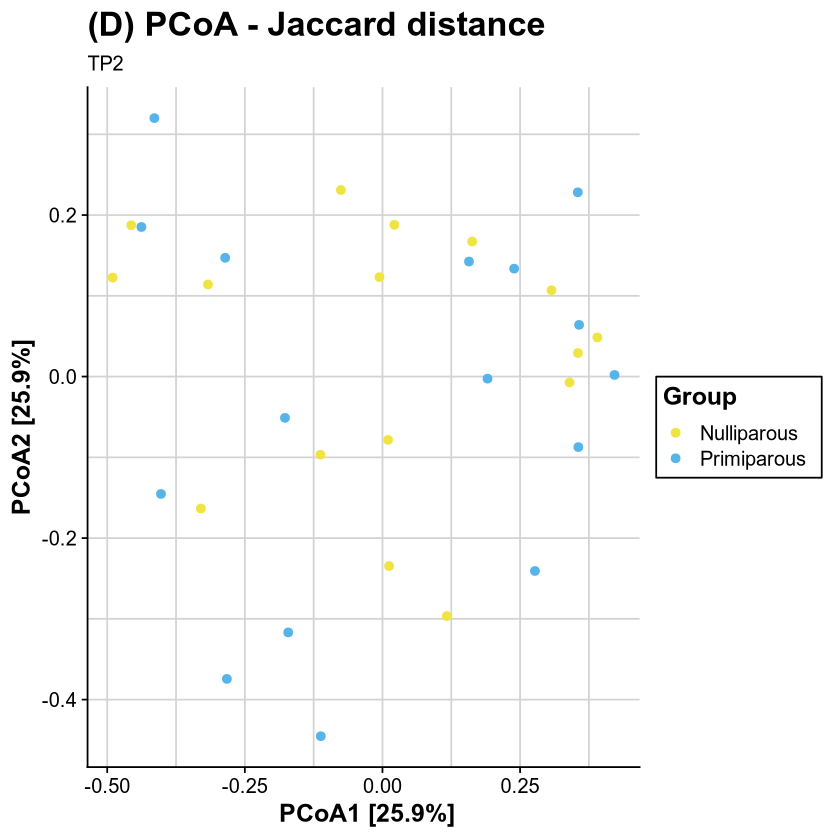

In [84]:
dye <- c("Nulliparous" = "#F0E442", "Primiparous" = "#56B4E9")

jaccard_plot <- jaccard_merged_tp2 |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", jaccard_dim2_tp2, "%]"),
        x = paste0(" PCoA1 [", jaccard_dim1_tp2, "%]"),
        title = "(D) PCoA - Jaccard distance",
        subtitle = "TP2"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color = "Black", size = 0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
         axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
jaccard_plot

## PERMANOVA THIS IS OUTPUT FOR FECAL!!! DID NOT RUN THIS ----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [37]:
set.seed(123)
adonis_Group <- adonis2(formula = jaccard_tp2 ~ Group, na.action = na.omit, data = adonis_tab_tp2)
# adonis_Group
# Rename "Model" to say Group, for better orientation
rownames(adonis_Group)[1] <- "Group"
adonis_Group
jaccard_pval <- adonis_Group[1,"Pr(>F)"]
jaccard_pval

jaccard_r2 <- adonis_Group[1, "R2"]
jaccard_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.1766341,0.01900566,0.5812161,0.866
Residual,30,9.1171282,0.98099434,NA,NA
Total,31,9.2937622,1.00000000,NA,NA


[1] 0.866

[1] 0.01900566

In [38]:
adonis_Age <- adonis2(formula = jaccard_tp2 ~ Age , na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_Age)[1] <- "Age"
adonis_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.3592031,0.03864991,1.206114,0.24
Residual,30,8.9345592,0.96135009,NA,NA
Total,31,9.2937622,1.00000000,NA,NA


In [39]:
set.seed(123)
adonis_bmigroups <- adonis2(formula = jaccard_tp2 ~ BMI_groups, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_bmigroups)[1] <- "BMI_groups"
adonis_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.8045742,0.09777741,1.354674,0.125
Residual,25,7.4240564,0.90222259,NA,NA
Total,27,8.2286306,1.00000000,NA,NA


In [40]:
adonis_group_bmi <- adonis2(formula = jaccard_tp2 ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_group_bmi)[1] <- "Group_BMI"
adonis_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_BMI,2,0.6474375,0.06966366,1.085761,0.333
Residual,29,8.6463247,0.93033634,NA,NA
Total,31,9.2937622,1.00000000,NA,NA


In [41]:
adonis_age_bmi <- adonis2(formula = jaccard_tp2 ~ Age + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_age_bmi)[1] <- "Age_BMI"
adonis_age_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_BMI,2,0.7833054,0.08428292,1.334585,0.147
Residual,29,8.5104569,0.91571708,NA,NA
Total,31,9.2937622,1.00000000,NA,NA


In [42]:
adonis_group_ab <- adonis2(formula = jaccard_tp2 ~ Group + Antibiotics, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_group_ab)[1] <- "Group_antibiotics"
adonis_group_ab

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_antibiotics,2,0.5429384,0.05841966,0.8996418,0.594
Residual,29,8.7508238,0.94158034,NA,NA
Total,31,9.2937622,1.00000000,NA,NA


In [43]:
adonis_agegroup_bmi <- adonis2(formula = jaccard_tp2 ~ Age_groups + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
# Rename "Model" for better orientation
rownames(adonis_agegroup_bmi)[1] <- "AgeGroup_BMI"
adonis_agegroup_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AgeGroup_BMI,2,0.728190,0.07835255,1.232697,0.187
Residual,29,8.565572,0.92164745,NA,NA
Total,31,9.293762,1.00000000,NA,NA


# Aitchison=========================================================================================================

## Robust Aitchison

In [44]:
aitchison <- ordered_taxa |>
   as.matrix() |>
    vegdist(method = "robust.aitchison")
head(aitchison)
head(as.matrix(aitchison))

[1]  3.218218  5.847580 26.116611 25.189565 14.400340 23.996158

,1,2,3,4,5,6,7,8,9,10,⋯,23,24,25,26,27,28,29,30,31,32
1,0.000000,3.218218,5.847580,26.116611,25.189565,14.40034,23.996158,5.245901,7.651835,10.274336,⋯,25.419933,12.89468,19.28957,4.458478,15.974524,11.132679,22.131987,14.64450,18.81211,13.427558
2,3.218218,0.000000,8.808147,24.770303,23.464242,12.23526,21.918658,2.557108,6.485991,7.931528,⋯,23.162009,13.79052,17.73836,2.143923,13.710907,11.152078,20.902773,12.73422,18.05439,12.999006
3,5.847580,8.808147,0.000000,26.818230,26.770387,17.22594,26.601418,10.636220,11.104766,14.293111,⋯,28.395748,11.18610,22.54942,9.574541,18.830291,10.627781,23.146044,16.94848,19.95827,13.494270
4,26.116611,24.770303,26.818230,0.000000,4.822051,15.70494,11.246460,23.951226,21.352409,18.906341,⋯,13.265173,18.95825,22.74844,23.474761,14.164178,17.797116,7.969112,13.29924,16.47621,18.166168
5,25.189565,23.464242,26.770387,4.822051,0.000000,15.06734,6.510202,22.200694,19.475112,16.602878,⋯,8.445663,18.89638,18.98430,21.925822,13.253929,18.661124,5.958647,12.71609,14.06193,19.348485
6,14.400340,12.235255,17.225944,15.704941,15.067344,0.00000,15.815968,12.071464,12.801371,9.688193,⋯,17.182341,16.55528,20.26030,11.859913,2.113042,9.145571,15.528267,2.91998,18.25866,8.112113


In [45]:
# Convert to matrix and re-assign proper row and column names since they did not transfer properly
aitchison_matrix <- as.matrix(aitchison)
rownames(aitchison_matrix) <- rownames(ordered_taxa)
colnames(aitchison_matrix) <- rownames(ordered_taxa)
head(aitchison_matrix)

,FF00531801,FF02014735,FF03816858,FF02015861,FF00657251,FF02015423,FF00657220,FF00531275,FF02014450,FF02740077,⋯,FF06039851,FF06743126,FF06032176,FF08440357,FF04761515,FF06743139,FF08440262,FF08440427,FF06033016,FF05024823
FF00531801,0.000000,3.218218,5.847580,26.116611,25.189565,14.40034,23.996158,5.245901,7.651835,10.274336,⋯,25.419933,12.89468,19.28957,4.458478,15.974524,11.132679,22.131987,14.64450,18.81211,13.427558
FF02014735,3.218218,0.000000,8.808147,24.770303,23.464242,12.23526,21.918658,2.557108,6.485991,7.931528,⋯,23.162009,13.79052,17.73836,2.143923,13.710907,11.152078,20.902773,12.73422,18.05439,12.999006
FF03816858,5.847580,8.808147,0.000000,26.818230,26.770387,17.22594,26.601418,10.636220,11.104766,14.293111,⋯,28.395748,11.18610,22.54942,9.574541,18.830291,10.627781,23.146044,16.94848,19.95827,13.494270
FF02015861,26.116611,24.770303,26.818230,0.000000,4.822051,15.70494,11.246460,23.951226,21.352409,18.906341,⋯,13.265173,18.95825,22.74844,23.474761,14.164178,17.797116,7.969112,13.29924,16.47621,18.166168
FF00657251,25.189565,23.464242,26.770387,4.822051,0.000000,15.06734,6.510202,22.200694,19.475112,16.602878,⋯,8.445663,18.89638,18.98430,21.925822,13.253929,18.661124,5.958647,12.71609,14.06193,19.348485
FF02015423,14.400340,12.235255,17.225944,15.704941,15.067344,0.00000,15.815968,12.071464,12.801371,9.688193,⋯,17.182341,16.55528,20.26030,11.859913,2.113042,9.145571,15.528267,2.91998,18.25866,8.112113


In [46]:
aitchison_pcoa <- wcmdscale(aitchison_matrix, eig = TRUE)
aitchison_points <- data.frame(aitchison_pcoa$points)
head(aitchison_points)
aitchison_merged <- aitchison_points |>
  rownames_to_column(var = "Sample_ID") |>
  left_join(adonis_tab_tp2, by = "Sample_ID")
head(aitchison_merged)

,Dim1,Dim2,Dim3
,<dbl>,<dbl>,<dbl>
FF00531801,-12.34241,-4.308656,-0.5422600
FF02014735,-10.90156,-3.190634,2.1093254
FF03816858,-13.03807,-4.417125,-6.3472994
FF02015861,10.61979,7.831775,-3.2670969
FF00657251,11.03656,4.997586,0.6118005
FF02015423,-3.74711,6.697129,2.9738920


,Sample_ID,Dim1,Dim2,Dim3,Group,Studynumber,Personalnumber,Age,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<int>,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF00531801,-12.34241,-4.308656,-0.5422600,Nulliparous,S194e21b,P159f9c8,36,4,Yes,60,21,1,0,0,0,0,NA
2,FF02014735,-10.90156,-3.190634,2.1093254,Nulliparous,S1f95844,P1f95844,30,3,No,64,22,1,0,0,0,1,18.5-25 Normal weight
3,FF03816858,-13.03807,-4.417125,-6.3472994,Nulliparous,S2b86cc0,P3cac7b0,31,3,No,56,21,1,0,0,0,0,18.5-25 Normal weight
4,FF02015861,10.61979,7.831775,-3.2670969,Nulliparous,S39fe1d7,P3db7da6,29,2,No,55,21,1,0,0,1,1,18.5-25 Normal weight
5,FF00657251,11.03656,4.997586,0.6118005,Nulliparous,S7e4a963,P424fd61,37,4,No,67,24,1,0,0,0,0,NA
6,FF02015423,-3.74711,6.697129,2.9738920,Nulliparous,S5fa4a39,P4de45e7,29,2,Yes,71,28,1,0,0,0,0,> 25 Overweight


In [47]:
head(aitchison_pcoa)

,Dim1,Dim2,Dim3
FF00531801,-12.3424082,-4.308656104,-0.5422600
FF02014735,-10.9015593,-3.190633544,2.1093254
FF03816858,-13.0380679,-4.417124553,-6.3472994
FF02015861,10.6197904,7.831775239,-3.2670969
FF00657251,11.0365610,4.997585889,0.6118005
FF02015423,-3.7471098,6.697128814,2.9738920
FF00657220,10.5464423,0.249084998,5.0383402
FF00531275,-8.9782616,-4.170189603,3.4805275
FF02014450,-5.0796450,-5.917533851,1.2506022
FF02740077,-3.1774261,-2.930588265,3.8923769


In [48]:
nrow(ordered_taxa)
length(aitchison_pcoa$eig)
eig_vals <- aitchison_pcoa$eig
# How many non-zero eigenvalues?
sum(eig_vals > 1e-6)  # Threshold to count "non-zero" dimensions

# Show all eigenvalues
eig_vals

[1] 32

[1] 3

[1] 3

[1] 2223.7108 1021.1146  495.3357

In [49]:
# Save the eigenvalues, add percentages for plot
aitchison_dim1 <- round(aitchison_pcoa$eig[1]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim2 <- round(aitchison_pcoa$eig[2]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim1
aitchison_dim2

[1] 59.5

[1] 27.3

In [50]:
aitchison_dim3 <- round(aitchison_pcoa$eig[3]/sum(aitchison_pcoa$eig)*100, digits = 1)
aitchison_dim4 <- round(aitchison_pcoa$eig[4]/sum(aitchison_pcoa$eig)*100,  digits = 1)
aitchison_dim3
aitchison_dim4

[1] 13.2

[1] NA

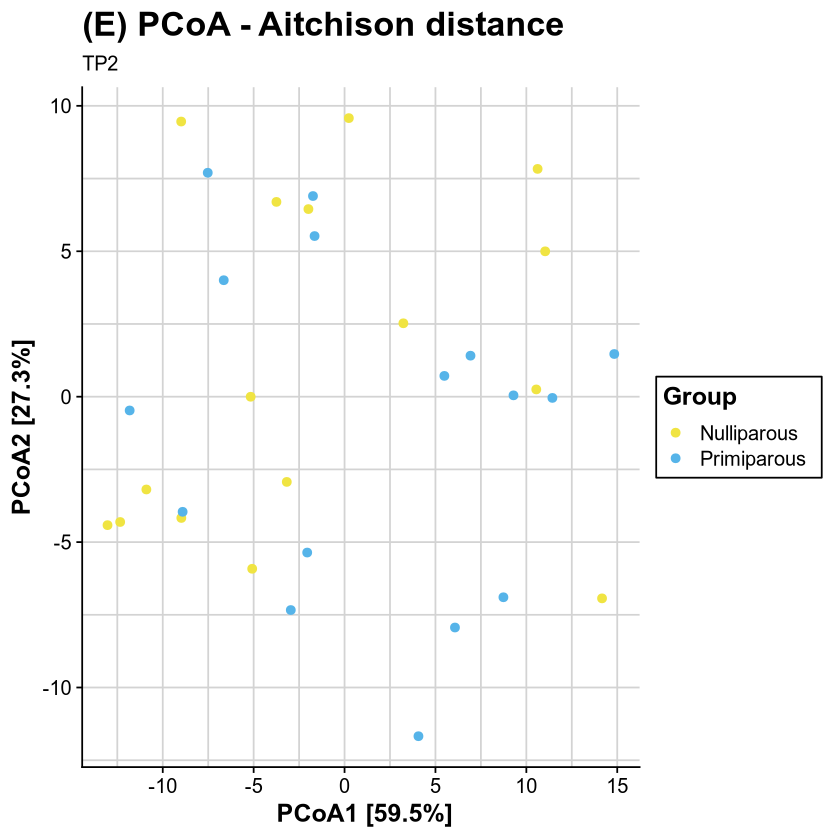

In [51]:
aitchison_plot <- aitchison_merged |>
    ggplot(aes(x = Dim1, y = Dim2, colour = Group)) +
    geom_point() +
    labs(
        y = paste0("PCoA2 [", aitchison_dim2, "%]"),
        x = paste0(" PCoA1 [", aitchison_dim1, "%]"),
        title = "(E) PCoA - Aitchison distance",
        subtitle = "TP2"
    ) +
    scale_colour_manual(values = dye) +
    theme_half_open() +
    #background_grid() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
)
    
aitchison_plot

## PERMANOVA SAME AS PERMANOVA ABOVE----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [52]:
set.seed(123)
adonis_ait_Group <- adonis2(formula = aitchison  ~ Group, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_Group)[1] <- "Group"
adonis_ait_Group
aitchison_pval <- adonis_ait_Group[1,"Pr(>F)"]
aitchison_pval

aitchison_r2 <- adonis_ait_Group[1, "R2"]
aitchison_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,121.6473,0.0325246,1.00854,0.371
Residual,30,3618.5138,0.9674754,NA,NA
Total,31,3740.1611,1.0000000,NA,NA


[1] 0.371

[1] 0.0325246

In [53]:
adonis_ait_Age <- adonis2(formula = aitchison  ~ Age, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_Age)[1] <- "Age"
adonis_ait_Age

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,242.8068,0.06491882,2.082776,0.105
Residual,30,3497.3542,0.93508118,NA,NA
Total,31,3740.1611,1.00000000,NA,NA


In [54]:
#head(adonis_tab)
adonis_ait_Agegroups <- adonis2(formula = aitchison ~ Age_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_Agegroups)[1] <- "Age_groups"
adonis_ait_Agegroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age_groups,1,136.5622,0.03651237,1.136881,0.354
Residual,30,3603.5989,0.96348763,NA,NA
Total,31,3740.1611,1.00000000,NA,NA


In [55]:
adonis_ait_bmigroups <- adonis2(formula = aitchison ~ BMI_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_bmigroups)[1] <- "BMI_groups"
adonis_ait_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,340.6178,0.1117044,1.571892,0.143
Residual,25,2708.6607,0.8882956,NA,NA
Total,27,3049.2784,1.0000000,NA,NA


In [56]:
adonis_ait_group_bmiprior <- adonis2(formula = aitchison ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_bmiprior)[1] <- "Group_bmi"
adonis_ait_group_bmiprior

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,313.5432,0.08383147,1.326782,0.275
Residual,29,3426.6179,0.91616853,NA,NA
Total,31,3740.1611,1.00000000,NA,NA


In [57]:
adonis_ait_group_bmigroups <- adonis2(formula = aitchison ~ Group + BMI_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_bmigroups)[1] <- "Group_bmi_groups"
adonis_ait_group_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi_groups,3,531.1866,0.1742007,1.687584,0.108
Residual,24,2518.0919,0.8257993,NA,NA
Total,27,3049.2784,1.0000000,NA,NA


In [58]:
adonis_ait_group_weight <- adonis2(formula = aitchison ~ Group + Weight_before_C, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_ait_group_weight)[1] <- "Group_weight"
adonis_ait_group_weight

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_weight,2,376.3787,0.1006317,1.622427,0.178
Residual,29,3363.7824,0.8993683,NA,NA
Total,31,3740.1611,1.0000000,NA,NA


# Bray curtis=======================================================================================================================================

In [59]:
bray_curt_dist <- vegdist(ordered_taxa, method = "bray")
head(as.matrix(bray_curt_dist))

,FF00531801,FF02014735,FF03816858,FF02015861,FF00657251,FF02015423,FF00657220,FF00531275,FF02014450,FF02740077,⋯,FF06039851,FF06743126,FF06032176,FF08440357,FF04761515,FF06743139,FF08440262,FF08440427,FF06033016,FF05024823
FF00531801,0.0000000,0.0057539,0.0277863,0.9995692,0.9993904,0.9993880,0.9994638,0.00413275,0.0029754,0.0223488,⋯,0.9995456,0.9994637,0.9994592,0.0072993,0.99700800,0.9978372,0.9998240,0.9995696,0.9998417,0.9955394
FF02014735,0.0057539,0.0000000,0.0261639,0.9988183,0.9983285,0.9977118,0.9983683,0.00722505,0.0068960,0.0211022,⋯,0.9986786,0.9983323,0.9979559,0.0046163,0.99384250,0.9957611,0.9992775,0.9982858,0.9997324,0.9927758
FF03816858,0.0277863,0.0261639,0.0000000,0.9982344,0.9981614,0.9995054,0.9982348,0.02813235,0.0293214,0.0279383,⋯,0.9982348,0.9979404,0.9979404,0.0252739,0.97467440,0.9747067,0.9982112,0.9982348,0.9982667,0.9688312
FF02015861,0.9995692,0.9988183,0.9982344,0.0000000,0.3446663,0.9241447,0.1881093,0.99555020,0.9994053,0.9794060,⋯,0.3013686,0.4658043,0.3055058,0.9982874,0.93471841,0.9407813,0.3059980,0.9072507,0.2845137,0.9392986
FF00657251,0.9993904,0.9983285,0.9981614,0.3446663,0.0000000,0.9021367,0.4822410,0.99557010,0.9974335,0.9787740,⋯,0.5924028,0.7520039,0.4122144,0.9982144,0.90769161,0.9191207,0.5884436,0.8807664,0.5217808,0.9175650
FF02015423,0.9993880,0.9977118,0.9995054,0.9241447,0.9021367,0.0000000,0.9103506,0.99804720,0.9989576,0.9871800,⋯,0.9095227,0.9902514,0.9892284,0.9945801,0.08040939,0.7407646,0.9971271,0.0472040,0.9833308,0.7041245


In [60]:
bray_curt_pcoa <- pco(bray_curt_dist)
#head(bray_curt_pcoa)

In [61]:
bray_vect <- bray_curt_pcoa$vectors
bray_curt_merged <- bray_vect |>
    rownames_to_column(var= "Sample_ID") |>
    left_join(adonis_tab_tp2, by = "Sample_ID")
head(bray_curt_merged)

,Sample_ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,⋯,Age_groups,excess_weight,Weight_before_C,BMI_prior,Primipara,Smoking,Alcohol,Antibiotics,High_stress,BMI_groups
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,FF00531801,-0.5204891,-0.33832132,0.016331950,-0.000648911,0.00770512,0.01253855,-0.007297034,-0.016051679,-0.0048716725,⋯,4,Yes,60,21,1,0,0,0,0,NA
2,FF02014735,-0.5201163,-0.33582433,0.015078021,-0.001204288,0.01043190,0.01187003,-0.006921306,-0.013334671,0.0002510852,⋯,3,No,64,22,1,0,0,0,1,18.5-25 Normal weight
3,FF03816858,-0.5235338,-0.31679610,0.004547921,0.017468610,0.01006196,0.01830576,-0.028022822,0.004227842,0.0750868291,⋯,3,No,56,21,1,0,0,0,0,18.5-25 Normal weight
4,FF02015861,0.4258293,-0.10563233,-0.087826429,-0.074558129,-0.10707118,-0.07342783,0.086298362,0.069536795,-0.0185960793,⋯,2,No,55,21,1,0,0,1,1,18.5-25 Normal weight
5,FF00657251,0.3067638,-0.01802965,-0.218844927,-0.230451672,-0.26992467,-0.17824622,-0.030753451,-0.062857685,0.0121411686,⋯,4,No,67,24,1,0,0,0,0,NA
6,FF02015423,-0.1225063,0.52015780,0.233637996,-0.241388955,0.02022846,0.05089195,0.072226556,-0.055770248,-0.0461612385,⋯,2,Yes,71,28,1,0,0,0,0,> 25 Overweight


In [62]:
bray_curt_df <- data.frame(Sample_ID = bray_curt_merged[,1],
                          Group = bray_curt_merged$Group,
                           pcoa1 = bray_curt_merged[,2],
                           pcoa2 = bray_curt_merged[,3],
                           pcoa3 = bray_curt_merged[,4]
                          )
head(bray_curt_df)

,Sample_ID,Group,pcoa1,pcoa2,pcoa3
,<chr>,<fct>,<dbl>,<dbl>,<dbl>
1,FF00531801,Nulliparous,-0.5204891,-0.33832132,0.016331950
2,FF02014735,Nulliparous,-0.5201163,-0.33582433,0.015078021
3,FF03816858,Nulliparous,-0.5235338,-0.31679610,0.004547921
4,FF02015861,Nulliparous,0.4258293,-0.10563233,-0.087826429
5,FF00657251,Nulliparous,0.3067638,-0.01802965,-0.218844927
6,FF02015423,Nulliparous,-0.1225063,0.52015780,0.233637996


In [63]:
# Save the eigenvalues, add percentages for plot
bray_dim1 <- round(bray_curt_pcoa$values[1]/sum(bray_curt_pcoa$values)*100, digits = 1)
bray_dim2 <- round(bray_curt_pcoa$values[2]/sum(bray_curt_pcoa$values)*100,  digits = 1)
bray_dim2
bray_dim1

[1] 32.1

[1] 44.8

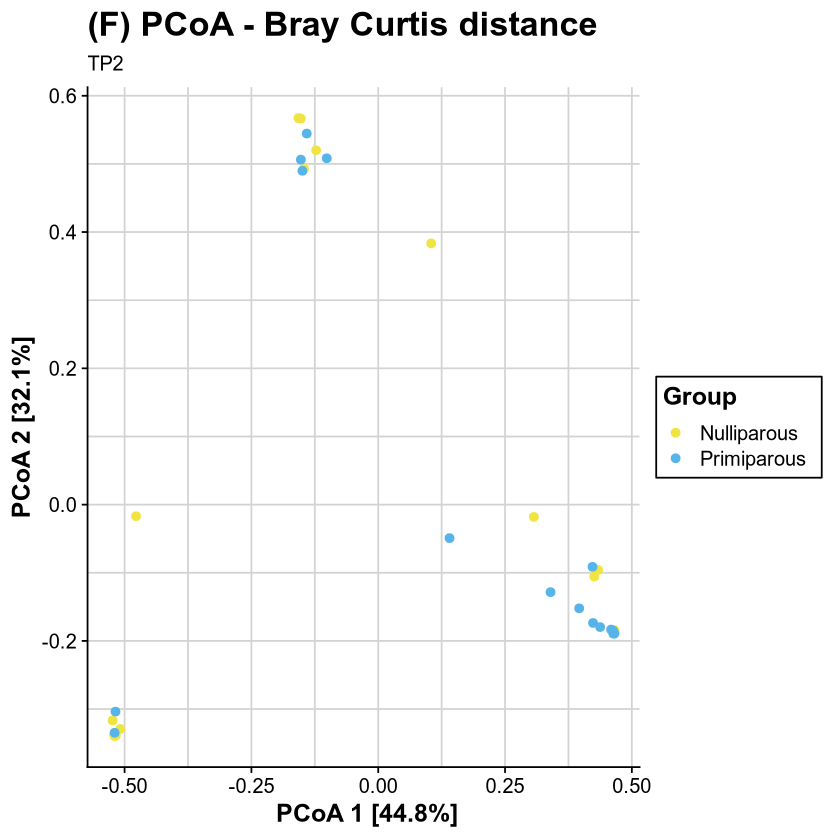

In [64]:
bray_plot <- bray_curt_df |>
    ggplot(aes(x = pcoa1, y = pcoa2, color = Group)) +
    geom_point() +
    labs(
        x = paste0(" PCoA 1 [", bray_dim1, "%]"),
        y = paste0("PCoA 2 [", bray_dim2, "%]"),
        title = "(F) PCoA - Bray Curtis distance",
        subtitle = "TP2"
    ) +
    scale_color_manual(values = dye) +
    theme_half_open() +
    theme( 
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")
     )

bray_plot

## PERMANOVA SAME AS ABOVE----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [65]:
set.seed(123)
adonis_bray_Group <- adonis2(formula = bray_curt_dist ~ Group, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_Group)[1] <- "Group"
adonis_bray_Group
bray_pval <- adonis_bray_Group[1,"Pr(>F)"]
bray_pval

bray_r2 <- adonis_bray_Group[1, "R2"]
bray_r2

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group,1,0.803813,0.07494963,2.430667,0.074
Residual,30,9.920896,0.92505037,NA,NA
Total,31,10.724709,1.00000000,NA,NA


[1] 0.074

[1] 0.07494963

In [66]:
adonis_bray_Age <- adonis2(formula = bray_curt_dist ~ Age, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_Age)[1] <- "Age"
adonis_bray_Age
#head(adonis_tab)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Age,1,0.7893626,0.07360224,2.383498,0.071
Residual,30,9.9353463,0.92639776,NA,NA
Total,31,10.7247089,1.00000000,NA,NA


In [67]:
adonis_bray_bmigroups <- adonis2(formula = bray_curt_dist ~ BMI_groups, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_bmigroups)[1] <- "BMI_groups"
adonis_bray_bmigroups

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BMI_groups,2,0.5650863,0.0596207,0.7925087,0.616
Residual,25,8.9129350,0.9403793,NA,NA
Total,27,9.4780213,1.0000000,NA,NA


In [68]:
adonis_bray_group_bmi <- adonis2(formula = bray_curt_dist ~ Group + BMI_prior, na.action = na.omit, data = adonis_tab_tp2)
rownames(adonis_bray_group_bmi)[1] <- "Group_bmi"
adonis_bray_group_bmi

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Group_bmi,2,1.457567,0.1359073,2.280608,0.049
Residual,29,9.267142,0.8640927,NA,NA
Total,31,10.724709,1.0000000,NA,NA


# Exporting data===============================================================================

In [69]:
#write.csv(jaccard_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_jaccard_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(aitchison_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_aitchison_merged_tp1", ".csv"), row.names = FALSE)

#write.csv(bray_curt_merged, file = paste0("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/tp1_nulliparous/tp1_alpha_beta_diversity/beta/", Sys.Date(), 
 #                                       "_bray_curt_df_tp1", ".csv"), row.names = FALSE)

# Combined plots --------------------------------------------------------------

In [78]:
# Extract legend from bray plot
legend_bray <- get_legend(bray_plot)

In [85]:
# remove legends so only one remains
plot_jaccard_nl <- jaccard_plot +  guides(fill = "none", color = "none") 
plot_aitch_nl <- aitchison_plot +  guides(fill = "none", color = "none") 
plot_bray_nl <- bray_plot +  guides(fill = "none", color = "none") 

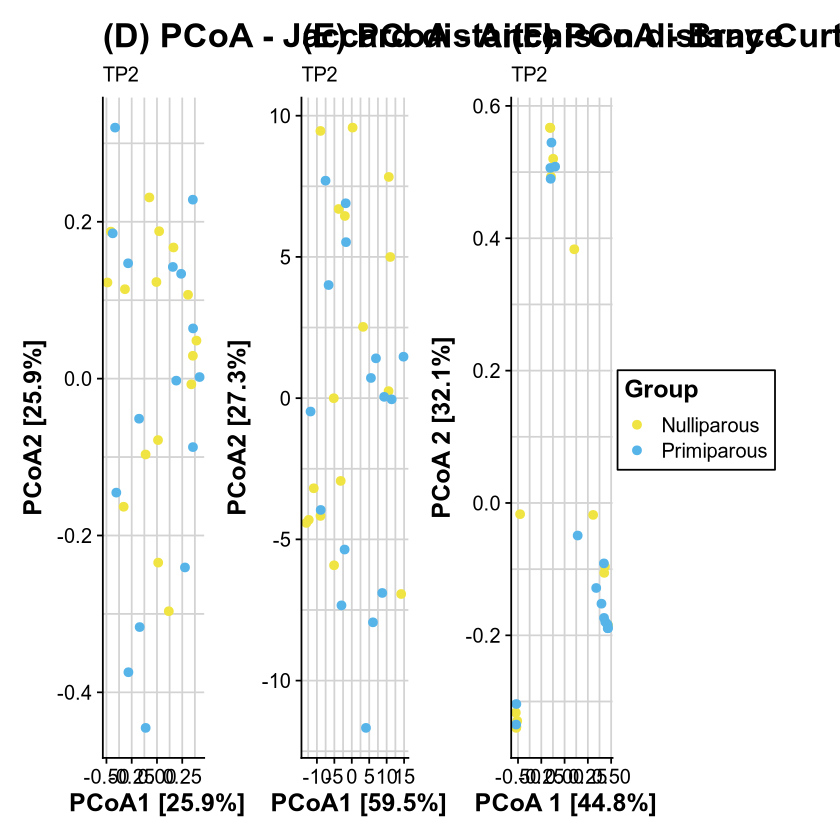

In [86]:
combined_plot <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, nrow =1) 

combined_plot_legend <- plot_grid(plot_jaccard_nl, plot_aitch_nl, plot_bray_nl, legend_bray, nrow =1) 


final_plot <- ggdraw(combined_plot_legend) +
  theme_half_open() +
  background_grid() +
  theme(
    axis.text.x = element_blank(),
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )
final_plot

In [87]:
#ggsave(file = paste0(Sys.Date(), "_vag_beta_tp2.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
 #      plot = final_plot, width = 19, height = 8)

# Bar plots -------------------------------------------------------------------------------------------

In [73]:
bar_df <- data.frame(
    Distance_metrics = c("Jaccard", "Aitchison", "Bray_Curtis"),
    Pvalue = c(jaccard_pval, aitchison_pval, bray_pval),
    R2 = c(jaccard_r2, aitchison_r2, bray_r2)
)
bar_df

Distance_metrics,Pvalue,R2
<chr>,<dbl>,<dbl>
Jaccard,0.866,0.01900566
Aitchison,0.371,0.03252460
Bray_Curtis,0.074,0.07494963


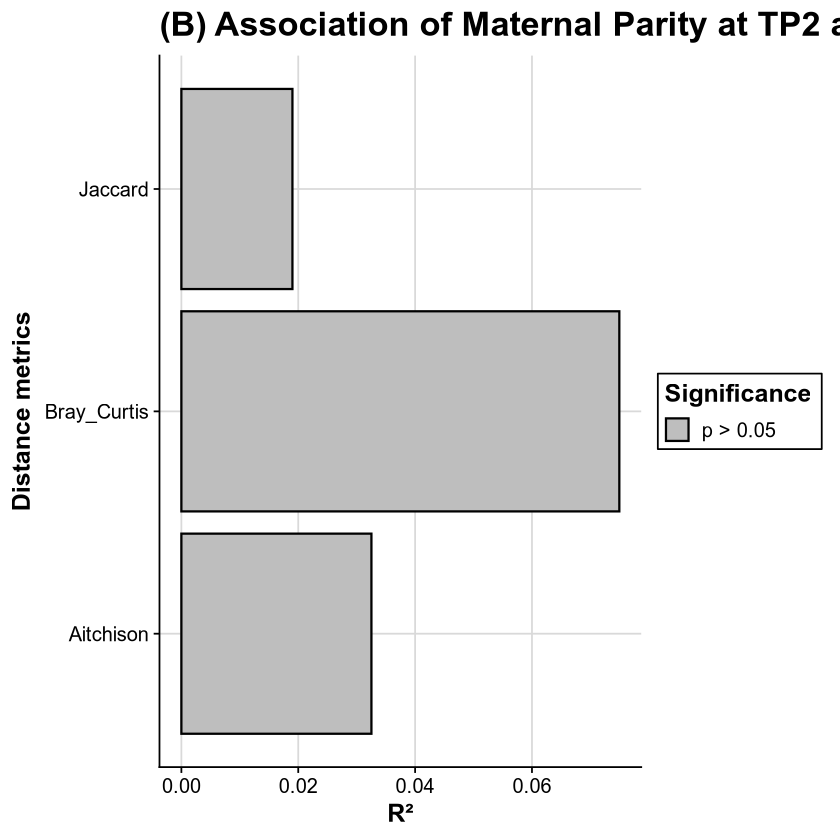

In [76]:
# Create column specifying p value greater or lesser
bar_df$Significance <- factor(ifelse(bar_df$Pvalue < 0.05, "p ≤ 0.05", "p > 0.05"))
dye_pval <- c("p ≤ 0.05" = "#0072B2", "p > 0.05" = "grey") # color vector 

#names(dye_pval) <- bar_df$Distance

bar_plot <- bar_df |>
    ggplot(aes(x = R2, y = Distance_metrics, fill = Significance)) +
    geom_col(colour = "black") +
    scale_fill_manual(values = dye_pval) +
    labs(title = "(B) Association of Maternal Parity at TP2 across Distance Metrics for the Vaginal Microbiome",
        x = "R²",
        y = "Distance metrics") +
    theme_half_open() +
    theme(
        legend.box.background = element_rect(color="Black", size=0.5),
        legend.box.margin = margin(4, 4, 4, 4),
        legend.title = element_text(face = "bold", size = 15),
        title = element_text(size = 18),
        axis.title.y = element_text(size = 15, face = "bold"),
        axis.title.x = element_text(size = 15, face = "bold"),
        panel.grid.major = element_line(colour = "lightgrey"),
        panel.grid.minor = element_line(colour = "lightgrey")) +
    background_grid()

bar_plot

In [77]:
#ggsave(file = paste0(Sys.Date(), "_vag_beta_tp2_bar.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
 #      plot = bar_plot, width = 14, height = 8)